In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

print("\nDataset Shape:", X.shape)

# Display first 5 rows
df = pd.DataFrame(X, columns=iris.feature_names)
df["Target"] = y
display(df.head())

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']

Dataset Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 120
Testing Samples : 30


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Normalization Completed")

Normalization Completed


In [5]:
model = Sequential()

# Input + Hidden Layer
model.add(Dense(16,
                activation='relu',
                input_shape=(4,)))

# Hidden Layer
model.add(Dense(8,
                activation='relu'))

# Output Layer
model.add(Dense(3,
                activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4271 - loss: 0.9586 - val_accuracy: 0.2500 - val_loss: 1.0595
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4375 - loss: 0.9051 - val_accuracy: 0.2500 - val_loss: 1.0116
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4792 - loss: 0.8603 - val_accuracy: 0.2917 - val_loss: 0.9769
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5104 - loss: 0.8220 - val_accuracy: 0.3750 - val_loss: 0.9483
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5521 - loss: 0.7891 - val_accuracy: 0.3750 - val_loss: 0.9268
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5729 - loss: 0.7624 - val_accuracy: 0.4167 - val_loss: 0.9076
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5938 - loss: 0.7389 - val_accuracy: 0.4167 - val_loss: 0.8895
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6250 - loss: 0.7165 - val_accuracy: 0.4583 - val_loss

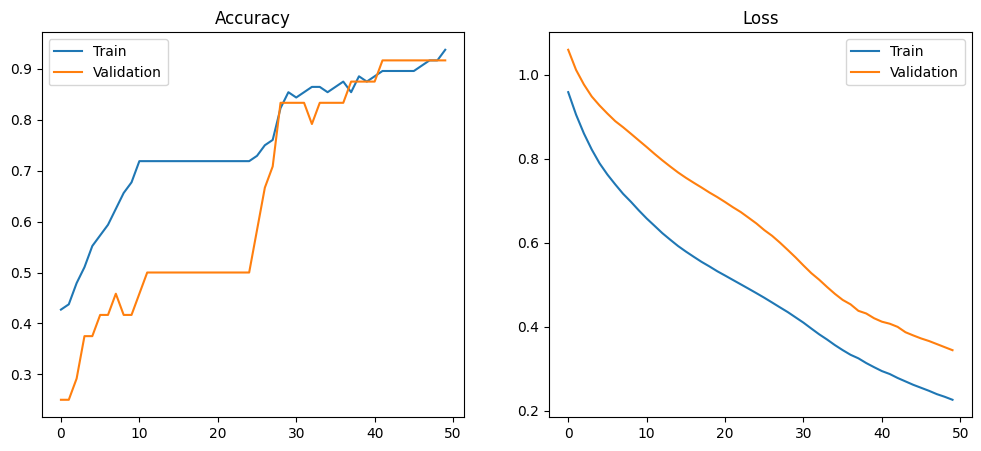

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label="Train")
plt.plot(history.history['val_accuracy'],label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label="Train")
plt.plot(history.history['val_loss'],label="Validation")
plt.title("Loss")
plt.legend()

plt.show()

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9667 - loss: 0.1994
Loss: 0.19939978420734406
Accuracy: 0.9666666388511658


In [10]:
predictions = model.predict(X_test)

print("Prediction Probabilities:")
print(predictions[0])

predicted_class = np.argmax(predictions[0])

print("\nPredicted Class :", predicted_class)
print("Actual Class    :", y_test[0])

print("Flower Name :", iris.target_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Prediction Probabilities:
[0.0170297  0.6507101  0.33226016]

Predicted Class : 1
Actual Class    : 1
Flower Name : versicolor


In [11]:
predictions = model.predict(X_test)

print("Prediction Probabilities:")
print(predictions[0])

predicted_class = np.argmax(predictions[0])

print("\nPredicted Class :", predicted_class)
print("Actual Class    :", y_test[0])

print("Flower Name :", iris.target_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction Probabilities:
[0.0170297  0.6507101  0.33226016]

Predicted Class : 1
Actual Class    : 1
Flower Name : versicolor


In [12]:
model1 = Sequential([
    Dense(32, activation='relu', input_shape=(4,)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

loss, acc = model1.evaluate(X_test,y_test,verbose=0)

print("Accuracy:",acc)

Accuracy: 0.9333333373069763


In [13]:
epochs_list = [10,50,100]

for ep in epochs_list:

    model = Sequential([
        Dense(16,activation='relu',input_shape=(4,)),
        Dense(8,activation='relu'),
        Dense(3,activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=ep,
        verbose=0
    )

    loss,acc=model.evaluate(X_test,y_test,verbose=0)

    print(f"Epochs={ep} Accuracy={acc:.4f}")

Epochs=10 Accuracy=0.7333
Epochs=50 Accuracy=0.9000
Epochs=100 Accuracy=0.9667


In [14]:
activations=["relu","sigmoid","tanh"]

for act in activations:

    model=Sequential([
        Dense(16,activation=act,input_shape=(4,)),
        Dense(8,activation=act),
        Dense(3,activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train,y_train,epochs=50,verbose=0)

    loss,acc=model.evaluate(X_test,y_test,verbose=0)

    print(act,"Accuracy:",acc)

relu Accuracy: 0.8999999761581421
sigmoid Accuracy: 0.8333333134651184
tanh Accuracy: 0.9666666388511658


In [15]:
optimizers=["adam","sgd","rmsprop"]

for opt in optimizers:

    model=Sequential([
        Dense(16,activation='relu',input_shape=(4,)),
        Dense(8,activation='relu'),
        Dense(3,activation='softmax')
    ])

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=50,
        verbose=0
    )

    loss,acc=model.evaluate(X_test,y_test,verbose=0)

    print(opt,"Accuracy:",acc)

adam Accuracy: 0.9666666388511658
sgd Accuracy: 0.800000011920929
rmsprop Accuracy: 0.8999999761581421


In [16]:
model=Sequential()

model.add(Dense(16,activation='relu',input_shape=(4,)))
model.add(Dense(8,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(3,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=50,
    verbose=0
)

loss,acc=model.evaluate(X_test,y_test,verbose=0)

print("Accuracy:",acc)

Accuracy: 0.8666666746139526
